# Module 09 — Systematic Market-Risk Diagnostics

Diagnostic-only test of S&P 500 exposure for the original static strategy.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
from src.backtest import run_walk_forward_backtest, backtest_summary

pd.set_option("display.max_columns", 120)
OUT = Path("data/processed/systematic_risk")
OUT.mkdir(parents=True, exist_ok=True)


In [2]:
train_prices = pd.read_parquet("data/processed/train_prices.parquet")
test_prices = pd.read_parquet("data/processed/test_prices.parquet")
eligible_pairs = pd.read_parquet("data/processed/eligible_pairs.parquet")
cointegrated_pairs = pd.read_parquet("data/processed/cointegrated_pairs.parquet")
rf_data = pd.read_parquet("data/processed/risk_free_rates.parquet")
risk_free_rates = rf_data.iloc[:,0] if isinstance(rf_data,pd.DataFrame) else pd.Series(rf_data)
risk_free_rates.index = pd.to_datetime(risk_free_rates.index)
risk_free_rates = risk_free_rates.sort_index().astype(float)

results = run_walk_forward_backtest(
    train_prices=train_prices, test_prices=test_prices,
    eligible_pairs=eligible_pairs, cointegrated_pairs=cointegrated_pairs,
    risk_free_rates=risk_free_rates, initial_capital=100000.0,
    entry_z=1.5, target_probability=0.70, memory_window=60,
    max_horizon_days=126, n_paths=5000, ewma_lambda=0.94, seed=42)

trades = results["trades"].copy()
equity = results["equity_curve"].copy()
summary = backtest_summary(trades,equity,100000.0)
display(summary.to_frame("value"))


,value
initial_capital,100000.000000
final_equity,132661.064555
total_return,0.326611
max_drawdown,-0.510505
n_trades,254.000000
win_rate,0.488189
average_trade_return,0.077734
median_trade_return,-0.040611
max_concurrent_positions,34.000000


In [3]:
start = pd.Timestamp(test_prices.index.min()).normalize()
end = pd.Timestamp(test_prices.index.max()).normalize() + pd.Timedelta(days=5)
sp = yf.download("^GSPC", start=start, end=end, auto_adjust=False, progress=False)
if sp.empty: raise RuntimeError("Could not download ^GSPC.")
if isinstance(sp.columns,pd.MultiIndex):
    col=("Adj Close","^GSPC") if ("Adj Close","^GSPC") in sp.columns else ("Close","^GSPC")
    spx=sp[col].copy()
else:
    spx=sp["Adj Close"].copy() if "Adj Close" in sp.columns else sp["Close"].copy()
spx.index=pd.to_datetime(spx.index).tz_localize(None).normalize()
spx=spx.astype(float).rename("sp500")
spx.to_frame().to_parquet(OUT/"sp500_prices.parquet")


In [4]:
eq=equity.copy()
if "date" in eq.columns:
    eq["date"]=pd.to_datetime(eq["date"]).dt.normalize()
    eq=eq.set_index("date")
eq.index=pd.to_datetime(eq.index).normalize()
strategy_return=eq["equity"].astype(float).pct_change().rename("strategy_return")
market_return=spx.pct_change().rename("market_return")
rf=risk_free_rates.copy()
rf.index=pd.to_datetime(rf.index).normalize()
rf=rf.reindex(eq.index,method="ffill")
rf_daily=((1+rf).pow(1/252)-1).rename("rf_daily")
data=pd.concat([strategy_return,market_return,rf_daily],axis=1).dropna()
data["strategy_excess"]=data["strategy_return"]-data["rf_daily"]
data["market_excess"]=data["market_return"]-data["rf_daily"]
data.to_parquet(OUT/"daily_market_alignment.parquet")
print("Aligned observations:",len(data))


Aligned observations: 754


## Full-period CAPM beta


In [5]:
def fit_beta(df):
    d=df[["strategy_excess","market_excess"]].dropna()
    X=sm.add_constant(d["market_excess"])
    return sm.OLS(d["strategy_excess"],X).fit(cov_type="HC3")
m=fit_beta(data)
full_capm=pd.Series({"alpha_daily":m.params["const"],"alpha_annualized_simple":m.params["const"]*252,"market_beta":m.params["market_excess"],"beta_std_error_HC3":m.bse["market_excess"],"beta_t_stat":m.tvalues["market_excess"],"beta_p_value":m.pvalues["market_excess"],"r_squared":m.rsquared,"n_obs":int(m.nobs)})
display(full_capm.to_frame("value"))
full_capm.to_frame("value").to_csv(OUT/"full_period_capm.csv")


,value
alpha_daily,0.000901
alpha_annualized_simple,0.227066
market_beta,-0.491944
beta_std_error_HC3,0.245711
beta_t_stat,-2.002126
beta_p_value,0.045271
r_squared,0.027473
n_obs,754.000000


## Annual beta


In [6]:
rows=[]
for year,g in data.groupby(data.index.year):
    if len(g)<30: continue
    a=fit_beta(g)
    rows.append({"year":int(year),"n_obs":int(a.nobs),"market_beta":a.params["market_excess"],"beta_std_error_HC3":a.bse["market_excess"],"beta_t_stat":a.tvalues["market_excess"],"beta_p_value":a.pvalues["market_excess"],"r_squared":a.rsquared})
annual_beta=pd.DataFrame(rows)
display(annual_beta)
annual_beta.to_parquet(OUT/"annual_beta.parquet",index=False)


,year,n_obs,market_beta,beta_std_error_HC3,beta_t_stat,beta_p_value,r_squared
0,2023,250,0.651811,0.178369,3.654284,2.579008e-04,0.059752
1,2024,252,0.196524,0.345954,0.568064,5.699916e-01,0.003125
2,2025,250,-1.374011,0.245322,-5.600841,2.133148e-08,0.233739


## Rolling 63-day beta and correlation


,count,mean,std,min,25%,50%,75%,max
beta_63d,692.0,0.284365,1.416008,-2.184987,-1.053375,0.521249,1.381519,2.704221
correlation_63d,692.0,0.030381,0.444365,-0.840174,-0.360354,0.149774,0.417151,0.653591


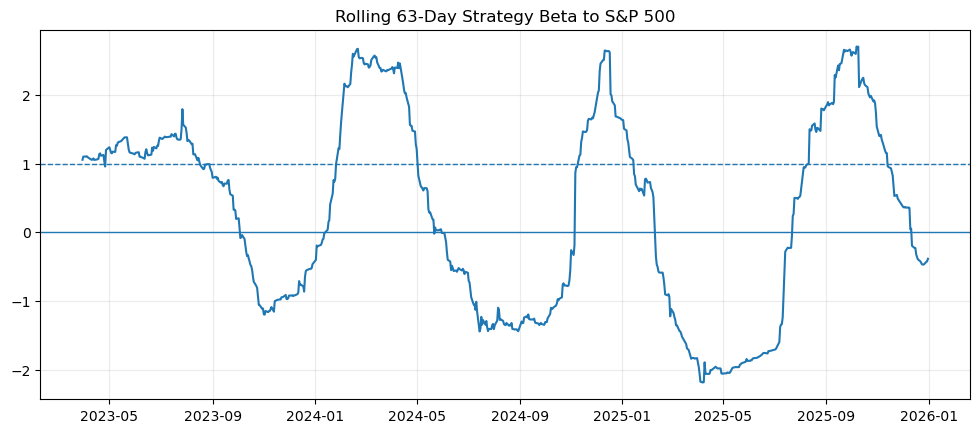

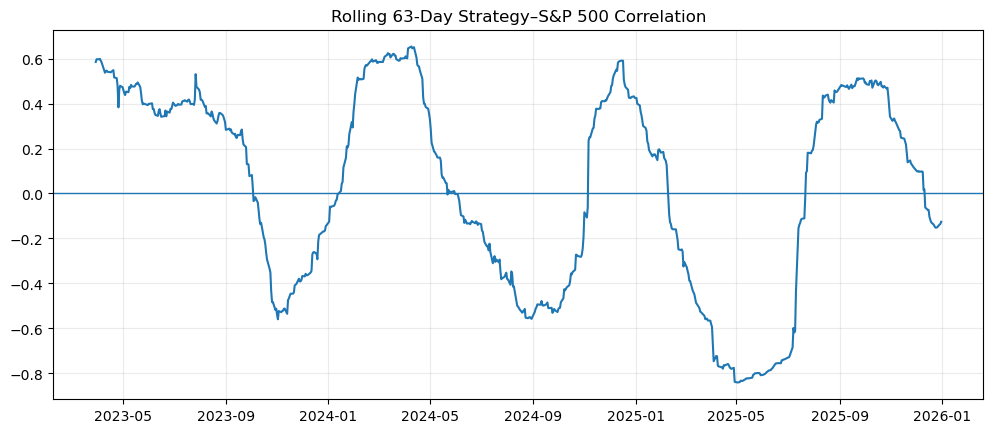

In [7]:
window=63
rolling=pd.DataFrame(index=data.index)
rolling["beta_63d"]=data["strategy_return"].rolling(window).cov(data["market_return"])/data["market_return"].rolling(window).var()
rolling["correlation_63d"]=data["strategy_return"].rolling(window).corr(data["market_return"])
rolling.to_parquet(OUT/"rolling_market_exposure.parquet")
display(rolling.dropna().describe().T)
plt.figure(figsize=(12,4.8)); plt.plot(rolling.index,rolling["beta_63d"]); plt.axhline(0,linewidth=1); plt.axhline(1,linewidth=1,linestyle="--"); plt.title("Rolling 63-Day Strategy Beta to S&P 500"); plt.grid(alpha=.25); plt.show()
plt.figure(figsize=(12,4.8)); plt.plot(rolling.index,rolling["correlation_63d"]); plt.axhline(0,linewidth=1); plt.title("Rolling 63-Day Strategy–S&P 500 Correlation"); plt.grid(alpha=.25); plt.show()


## Upside and downside beta


In [8]:
def row(name,g):
    a=fit_beta(g)
    return {"sample":name,"n_obs":int(a.nobs),"market_beta":a.params["market_excess"],"beta_std_error_HC3":a.bse["market_excess"],"beta_t_stat":a.tvalues["market_excess"],"beta_p_value":a.pvalues["market_excess"],"r_squared":a.rsquared}
asymmetry=pd.DataFrame([row("down_market_days",data.loc[data["market_return"]<0]),row("up_market_days",data.loc[data["market_return"]>=0])])
display(asymmetry)
asymmetry.to_parquet(OUT/"upside_downside_beta.parquet",index=False)


,sample,n_obs,market_beta,beta_std_error_HC3,beta_t_stat,beta_p_value,r_squared
0,down_market_days,329,-1.630618,0.426175,-3.826167,0.000130,0.153111
1,up_market_days,425,-0.413851,0.817583,-0.506188,0.612725,0.010507


## Maximum-drawdown-window beta


In [9]:
eq2=eq.copy(); eq2["running_max"]=eq2["equity"].cummax(); eq2["drawdown"]=eq2["equity"]/eq2["running_max"]-1
trough_date=eq2["drawdown"].idxmin(); peak_date=eq2.loc[:trough_date,"equity"].idxmax()
dd_data=data.loc[(data.index>=peak_date)&(data.index<=trough_date)]
dm=fit_beta(dd_data)
dd_beta=pd.Series({"peak_date":peak_date,"trough_date":trough_date,"max_drawdown":eq2.loc[trough_date,"drawdown"],"n_obs":int(dm.nobs),"market_beta":dm.params["market_excess"],"beta_std_error_HC3":dm.bse["market_excess"],"beta_t_stat":dm.tvalues["market_excess"],"beta_p_value":dm.pvalues["market_excess"],"r_squared":dm.rsquared})
display(dd_beta.to_frame("value")); dd_beta.to_frame("value").to_csv(OUT/"max_drawdown_beta.csv")


,value
peak_date,2025-04-10 00:00:00
trough_date,2025-10-10 00:00:00
max_drawdown,-0.510505
n_obs,127
market_beta,-0.380133
beta_std_error_HC3,0.800867
beta_t_stat,-0.474652
beta_p_value,0.635035
r_squared,0.012931


## Stress-day conditional performance


In [10]:
q05=data["market_return"].quantile(.05)
masks={"market_down_gt_1pct":data["market_return"]<-0.01,"market_down_gt_2pct":data["market_return"]<-0.02,"worst_5pct_market_days":data["market_return"]<=q05,"other_95pct_market_days":data["market_return"]>q05}
rows=[]
for name,mask in masks.items():
    g=data.loc[mask]
    rows.append({"sample":name,"n_days":len(g),"mean_market_return":g["market_return"].mean(),"mean_strategy_return":g["strategy_return"].mean(),"median_strategy_return":g["strategy_return"].median(),"strategy_win_rate":(g["strategy_return"]>0).mean()})
stress=pd.DataFrame(rows); display(stress); stress.to_parquet(OUT/"stress_day_performance.parquet",index=False)


,sample,n_days,mean_market_return,mean_strategy_return,median_strategy_return,strategy_win_rate
0,market_down_gt_1pct,76,-0.016508,0.013825,0.011630,0.565789
1,market_down_gt_2pct,12,-0.030551,0.050882,0.043745,0.666667
2,worst_5pct_market_days,38,-0.020861,0.022325,0.016979,0.631579
3,other_95pct_market_days,716,0.001983,-0.000382,-0.003050,0.438547


## Worst strategy days and market moves


In [11]:
worst=data.nsmallest(25,"strategy_return")[["strategy_return","market_return","strategy_excess","market_excess"]]
display(worst); worst.to_parquet(OUT/"worst_strategy_days.parquet")


,strategy_return,market_return,strategy_excess,market_excess
2025-04-09,-0.138322,0.095154,-0.138486,0.094990
2025-08-05,-0.067284,-0.004858,-0.067445,-0.005019
2024-04-23,-0.059426,0.011965,-0.059629,0.011762
2025-07-22,-0.056827,0.000638,-0.056992,0.000473
2024-08-08,-0.051396,0.023043,-0.051592,0.022846
2025-03-24,-0.051077,0.017646,-0.051239,0.017483
2024-02-20,-0.049746,-0.006005,-0.049947,-0.006207
2023-07-27,-0.049400,-0.006425,-0.049604,-0.006628
2025-01-14,-0.049285,0.001146,-0.049449,0.000983
2025-10-21,-0.048326,0.000033,-0.048473,-0.000115


## Nonlinear market exposure


In [12]:
quad=data[["strategy_return","market_return"]].dropna().copy(); quad["market_return_sq"]=quad["market_return"]**2
X=sm.add_constant(quad[["market_return","market_return_sq"]]); qm=sm.OLS(quad["strategy_return"],X).fit(cov_type="HC3")
quadratic=pd.Series({"alpha_daily":qm.params["const"],"beta_linear":qm.params["market_return"],"beta_squared":qm.params["market_return_sq"],"beta_squared_p_value":qm.pvalues["market_return_sq"],"r_squared":qm.rsquared,"n_obs":int(qm.nobs)})
display(quadratic.to_frame("value")); quadratic.to_frame("value").to_csv(OUT/"quadratic_market_regression.csv")


,value
alpha_daily,0.000963
beta_linear,-0.509056
beta_squared,2.459181
beta_squared_p_value,0.952356
r_squared,0.028531
n_obs,754.000000


## Normalized performance and drawdowns


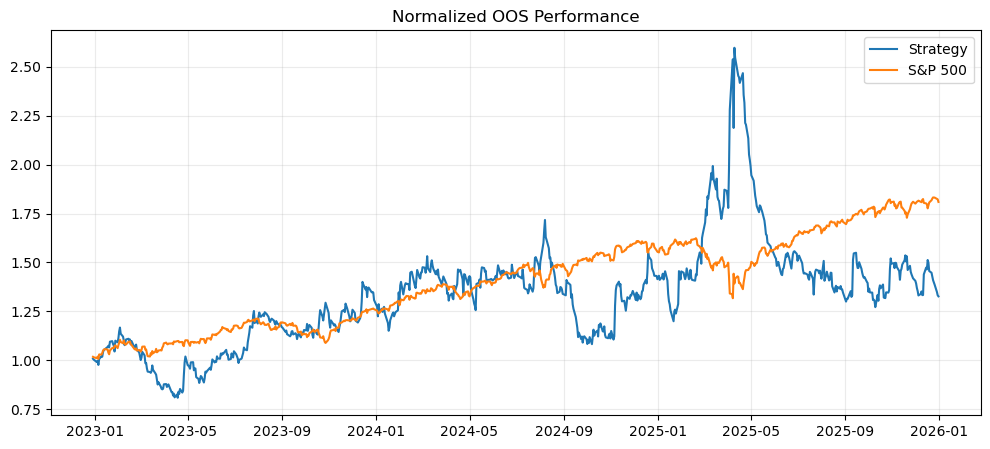

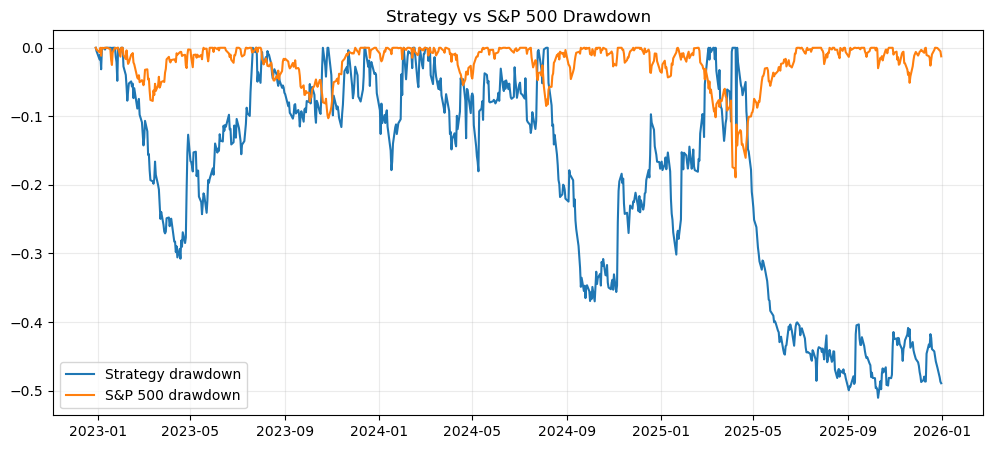

In [13]:
plot_df=pd.concat([(1+data["strategy_return"]).cumprod().rename("strategy"),(1+data["market_return"]).cumprod().rename("sp500")],axis=1)
plt.figure(figsize=(12,5)); plt.plot(plot_df.index,plot_df["strategy"],label="Strategy"); plt.plot(plot_df.index,plot_df["sp500"],label="S&P 500"); plt.title("Normalized OOS Performance"); plt.grid(alpha=.25); plt.legend(); plt.show()
sdd=plot_df["strategy"]/plot_df["strategy"].cummax()-1; mdd=plot_df["sp500"]/plot_df["sp500"].cummax()-1
plt.figure(figsize=(12,5)); plt.plot(sdd.index,sdd,label="Strategy drawdown"); plt.plot(mdd.index,mdd,label="S&P 500 drawdown"); plt.title("Strategy vs S&P 500 Drawdown"); plt.grid(alpha=.25); plt.legend(); plt.show()


## Diagnostic scorecard


In [14]:
full_beta=float(full_capm["market_beta"]); down_beta=float(asymmetry.loc[asymmetry["sample"]=="down_market_days","market_beta"].iloc[0]); up_beta=float(asymmetry.loc[asymmetry["sample"]=="up_market_days","market_beta"].iloc[0]); drawdown_beta=float(dd_beta["market_beta"])
score=pd.DataFrame([{"question":"Full-period market beta statistically non-zero?","result":"YES" if full_capm["beta_p_value"]<.05 else "NO / INCONCLUSIVE","evidence":f"beta={full_beta:.3f}, p={full_capm['beta_p_value']:.4f}"},{"question":"Downside beta exceeds upside beta?","result":"YES" if down_beta>up_beta else "NO","evidence":f"down={down_beta:.3f}, up={up_beta:.3f}"},{"question":"Drawdown-window beta exceeds full-period beta?","result":"YES" if drawdown_beta>full_beta else "NO","evidence":f"drawdown={drawdown_beta:.3f}, full={full_beta:.3f}"},{"question":"Evidence of nonlinear market exposure?","result":"YES" if quadratic["beta_squared_p_value"]<.05 else "NO / INCONCLUSIVE","evidence":f"quadratic p={quadratic['beta_squared_p_value']:.4f}"}])
display(score); score.to_csv(OUT/"systematic_risk_scorecard.csv",index=False); print("Outputs saved to:",OUT)


,question,result,evidence
0,Full-period market beta statistically non-zero?,YES,"beta=-0.492, p=0.0453"
1,Downside beta exceeds upside beta?,NO,"down=-1.631, up=-0.414"
2,Drawdown-window beta exceeds full-period beta?,YES,"drawdown=-0.380, full=-0.492"
3,Evidence of nonlinear market exposure?,NO / INCONCLUSIVE,quadratic p=0.9524


Outputs saved to: data\processed\systematic_risk


## Interpretation guardrail

A positive market beta does not follow mechanically from buying options. The cointegration hedge ratio is not a CAPM beta, and option deltas evolve after entry. Systematic exposure therefore has to be measured empirically.

This module is diagnostic only. Any future market filter, dynamic hedge, or volatility-state rule motivated by these OOS results would be a post-hoc extension, not an untouched out-of-sample specification.
